<a href="https://colab.research.google.com/github/JDavid-Moreno/IAIA-Proyecto2/blob/main/Proyecto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto: Clasificación de señales de Kepler con un perceptrón simple

## Equipo Azul
### Daniel Felipe Sua Siempira
### Juan David Moreno D'Aleman

## 1. Problema a abordar

La misión Kepler de la NASA observó el brillo de aproximadamente 10.000 candidatos
buscando pequeñas caídas periódicas de luz (tránsitos) causadas por un planeta
que pasa frente a su estrella. Cada señal detectada se registra como un
*Kepler Object of Interest* (KOI). Sin embargo, no toda señal es un planeta:
muchas son **falsos positivos** (binarias eclipsantes, ruido instrumental,
contaminación de estrellas cercanas, etc.).

**Objetivo:** construir un perceptrón simple que, a partir de las características
del tránsito y de la estrella, prediga si una señal corresponde a un
**exoplaneta confirmado** o a un **falso positivo**.

Este problema es relevante porque confirmar planetas requiere análisis y
observaciones costosas; un modelo que priorice las señales más prometedoras
ahorra tiempo de revisión.

## 2. Dataset

- **Fuente:** Kepler Objects of Interest (tabla acumulativa), [Enlace del data set](https://www.kaggle.com/datasets/nasa/kepler-exoplanet-search-results?resource=download).
- **Formato:** CSV tabular, 9.564 filas y 50 columnas.
- **Variable de disposición (`koi_disposition`):** CONFIRMED (2.293),
  FALSE POSITIVE (5.023) y CANDIDATE (2.248).
- Las señales CANDIDATE aún no tienen veredicto, por lo que **no se usan para
  entrenar ni evaluar**. Quedan 7.316 filas etiquetadas
  (31 % confirmados, 69 % falsos positivos).

## 3. Diseño del problema

**Tipo de problema:** clasificación binaria (predicción categórica).

**Variable objetivo (y):**
- `1` = CONFIRMED (exoplaneta confirmado)
- `0` = FALSE POSITIVE

**Características de entrada (X):**

| Grupo    | Variables                                                                |
|----------|--------------------------------------------------------------------------|
| Tránsito | `koi_period`, `koi_duration`, `koi_depth`, `koi_impact`, `koi_model_snr` |
| Planeta  | `koi_prad`, `koi_teq`, `koi_insol`                                       |
| Estrella | `koi_steff`, `koi_slogg`, `koi_srad`, `koi_kepmag`                       |

**Columnas excluidas y por qué:**
- Identificadores y texto (`rowid`, `kepid`, `kepoi_name`, `kepler_name`,
  `koi_tce_delivname`): no describen la física de la señal.
- `koi_pdisposition` y `koi_score`: son salidas de otros clasificadores del
  pipeline de Kepler; usarlas sería **fuga de información** (*data leakage*).
- Columnas `_err1/_err2`: se omiten para mantener el modelo simple
  (`koi_teq_err1/2` además están 100 % vacías).
- `koi_fpflag_*` (banderas de falso positivo): excluirlas
  en el modelo principal y compararlas como experimento adicional, porque
  casi revelan la respuesta.

**Preprocesamiento planeado:**
1. Imputar nulos con la mediana (calculada solo con el conjunto de entrenamiento).
2. Aplicar `log1p` a las variables muy sesgadas (`koi_period`, `koi_depth`,
   `koi_prad`, `koi_insol`).
3. Estandarizar las características con media y desviación del entrenamiento.
4. División entrenamiento/prueba [80 % / 20 %], estratificada por clase.

## 4. Diseño del modelo

Usaremos un **perceptrón simple**: una única neurona (una capa `Dense` de
1 unidad en Keras) que conecta las 12 entradas con la salida.

$$z = \mathbf{w} \cdot \mathbf{x} + b \qquad \hat{y} = \sigma(z) = \frac{1}{1 + e^{-z}}$$

| Componente           | Elección                                               | Justificación                                                                                                                                           |
|----------------------|--------------------------------------------------------|---------------------------------------------------------------------------------------------------------------------------------------------------------|
| Activación de salida | Sigmoide                                               | Entrega un valor en (0, 1) interpretable como la probabilidad de que la señal sea un exoplaneta confirmado. Es adecuada para clasificación binaria.     |
| Función de pérdida   | Entropía cruzada binaria (BCE)                         | Es la pérdida asociada a la sigmoide en clasificación: penaliza fuertemente las predicciones seguras pero equivocadas y da gradientes bien comportados. |
| Optimizador          | Descenso de gradiente (SGD), tasa de aprendizaje [0.1] | Es el algoritmo de descenso de gradiente visto en el curso.                                                                                             |
| Métricas             | Accuracy, precision, recall, F1 y matriz de confusión  | Las clases están desbalanceadas (31 % / 69 %), por lo que accuracy sola no basta.                                                                       |
| Regla de decisión    | $\hat{y} \ge 0.5 \Rightarrow$ exoplaneta               | Umbral estándar.                                                                                                                                        |

**Limitación asumida:** al ser un modelo lineal, solo puede separar las clases con
un hiperplano. Evaluaremos qué tan bien lo logra y discutiremos qué se ganaría con
redes más profundas (fuera del alcance de este proyecto).

## 5. Qué reutilizamos del Laboratorio 04

| Del laboratorio                                                  | Uso en este proyecto                                 |
|------------------------------------------------------------------|------------------------------------------------------|
| `sigmoid`, `binary_cross_entropy`, `accuracy`, `precision`       | Mismas funciones; se agregan recall y F1.            |
| Modelo Keras (`Dense(1, sigmoid)`, `SGD`, `binary_crossentropy`) | Modelo principal; solo cambia el número de entradas. |
| Clase `Perceptron` (NumPy)                                       | Comparación opcional manual vs. Keras.               |
| Curva de pérdida por época                                       | Evidencia de que el modelo aprende.                  |
| Gráfica de pesos por característica                              | Interpretar qué variables influyen más.              |
| Experimentos de normalización y *learning rate*                  | Justificar el preprocesamiento y la tasa elegida.    |

**Lo nuevo respecto al laboratorio:** división entrenamiento/prueba (en el lab se
evaluó con los mismos datos), preprocesamiento calculado solo con el entrenamiento,
imputación de nulos (en lugar de `dropna`), transformación logarítmica, EDA y
matriz de confusión con recall y F1.

## Carga, limpieza y división de datos

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow import keras
from tensorflow.keras import layers

df_kepler = pd.read_csv("cumulative.csv")
print(f"Forma original: {df_kepler.shape}")
print(df_kepler["koi_disposition"].value_counts())

Forma original: (9564, 50)
koi_disposition
FALSE POSITIVE    5023
CONFIRMED         2293
CANDIDATE         2248
Name: count, dtype: int64


In [ ]:
# quitar los "CANDIDATE"
df_kepler_copy = df_kepler[df_kepler["koi_disposition"] != "CANDIDATE"].copy()

In [ ]:
# Convertir a binario (1 CONFIRMED Y 0 FLASE POSITIVE)
df_kepler_copy["target"] = (df_kepler_copy["koi_disposition"] == "CONFIRMED").astype(int)

In [ ]:
df_kepler_copy.head()

,rowid,kepid,kepoi_name,kepler_name,koi_disposition,koi_pdisposition,koi_score,koi_fpflag_nt,koi_fpflag_ss,koi_fpflag_co,...,koi_slogg,koi_slogg_err1,koi_slogg_err2,koi_srad,koi_srad_err1,koi_srad_err2,ra,dec,koi_kepmag,target
0,1,10797460,K00752.01,Kepler-227 b,CONFIRMED,CANDIDATE,1.000,0,0,0,...,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347,1
1,2,10797460,K00752.02,Kepler-227 c,CONFIRMED,CANDIDATE,0.969,0,0,0,...,4.467,0.064,-0.096,0.927,0.105,-0.061,291.93423,48.141651,15.347,1
2,3,10811496,K00753.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,0,...,4.544,0.044,-0.176,0.868,0.233,-0.078,297.00482,48.134129,15.436,0
3,4,10848459,K00754.01,NaN,FALSE POSITIVE,FALSE POSITIVE,0.000,0,1,0,...,4.564,0.053,-0.168,0.791,0.201,-0.067,285.53461,48.285210,15.597,0
4,5,10854555,K00755.01,Kepler-664 b,CONFIRMED,CANDIDATE,1.000,0,0,0,...,4.438,0.070,-0.210,1.046,0.334,-0.133,288.75488,48.226200,15.509,1


In [ ]:
features = ["koi_period", "koi_duration", "koi_depth", "koi_impact", "koi_model_snr",
            "koi_prad", "koi_teq", "koi_insol",
            "koi_steff", "koi_slogg", "koi_srad", "koi_kepmag"]
df_kepler_copy = df_kepler_copy[features + ["target"]]

In [ ]:
print(f"Forma tras filtrar: {df_kepler_copy.shape}, % confirmados: {df_kepler_copy['target'].mean():.2%}")
print(df_kepler_copy[features].isna().sum())

Forma tras filtrar: (7316, 13), % confirmados: 31.34%
koi_period         0
koi_duration       0
koi_depth        300
koi_impact       300
koi_model_snr    300
koi_prad         300
koi_teq          300
koi_insol        259
koi_steff        300
koi_slogg        300
koi_srad         300
koi_kepmag         1
dtype: int64


In [ ]:
print(df_kepler_copy.shape)
print(df_kepler_copy["target"].value_counts())

(7316, 13)
target
0    5023
1    2293
Name: count, dtype: int64


In [ ]:
# Mirar la cantidad de nulos del dataset
print(df_kepler_copy.isnull().sum())

koi_period         0
koi_duration       0
koi_depth        300
koi_impact       300
koi_model_snr    300
koi_prad         300
koi_teq          300
koi_insol        259
koi_steff        300
koi_slogg        300
koi_srad         300
koi_kepmag         1
target             0
dtype: int64


In [ ]:
#Revisar cuantas filas tienen al menos un nulo
print(df_kepler_copy.isnull().any(axis=1).sum())

301


In [ ]:
# 1. Filas con algún nulo y su proporción de confirmados
mascara = df_kepler_copy.isnull().any(axis=1)
con_nulos = df_kepler_copy[mascara]

print("Filas con nulos:", con_nulos.shape[0])
print("% confirmados en filas con nulos:", round(con_nulos["target"].mean() * 100, 1))
print("% confirmados en todo el dataset:", round(df_kepler_copy["target"].mean() * 100, 1))

# 2. Eliminar las filas con nulos
df_kepler_copy = df_kepler_copy.dropna().reset_index(drop=True)

# 3. Verificar
print("Forma tras dropna:", df_kepler_copy.shape)       # esperado: (7015, 13)
print(df_kepler_copy["target"].value_counts())
print("% confirmados tras dropna:", round(df_kepler_copy["target"].mean() * 100, 1))

# 4. Separar X e y
X = df_kepler_copy[features]
y = df_kepler_copy["target"]
print(X.shape, y.shape)

Filas con nulos: 301
% confirmados en filas con nulos: 0.3
% confirmados en todo el dataset: 31.3
Forma tras dropna: (7015, 13)
target
0    4723
1    2292
Name: count, dtype: int64
% confirmados tras dropna: 32.7
(7015, 12) (7015,)


Eliminamos 301 filas (aprox 4.1 % de los datos) con valores faltantes. Verificamos que casi todas eran falsos positivos (solo 1 confirmado), así que los nulos no eran aleatorios. Eliminarlas movió el balance de 31.3 % a 32.7 %.
Como limitación, el modelo no aprende a reconocer señales con parámetros incompletos.

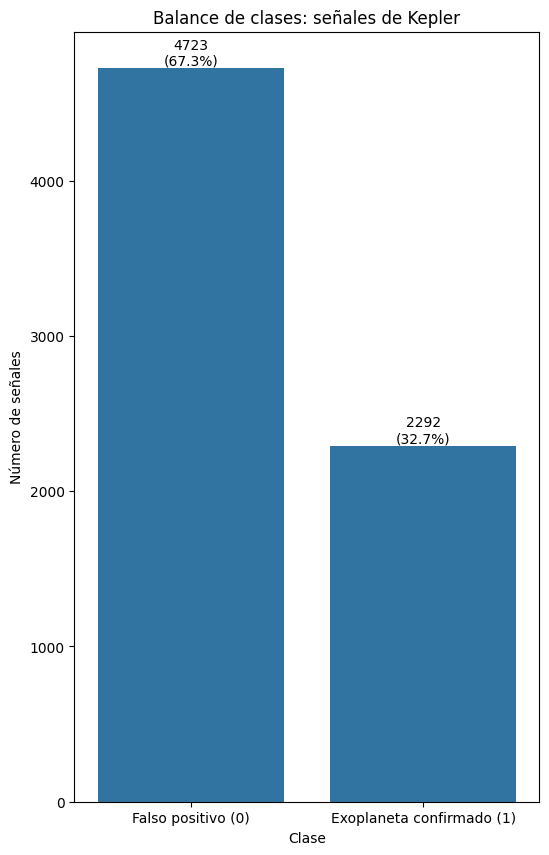

In [ ]:
#Balance de clases
plt.figure(figsize=(6,10))
ax = sns.countplot(x="target", data=df_kepler_copy)

ax.set_title("Balance de clases: señales de Kepler")
ax.set_xlabel("Clase")
ax.set_ylabel("Número de señales")
ax.set_xticks([0, 1])
ax.set_xticklabels(["Falso positivo (0)", "Exoplaneta confirmado (1)"])

# conteo y el porcentaje encima de cada barra
total = len(df_kepler_copy)
for barra in ax.patches:
    n = int(barra.get_height())
    ax.annotate(f"{n}\n({n / total * 100:.1f}%)",
                (barra.get_x() + barra.get_width() / 2, n),
                ha="center", va="bottom")

plt.show()

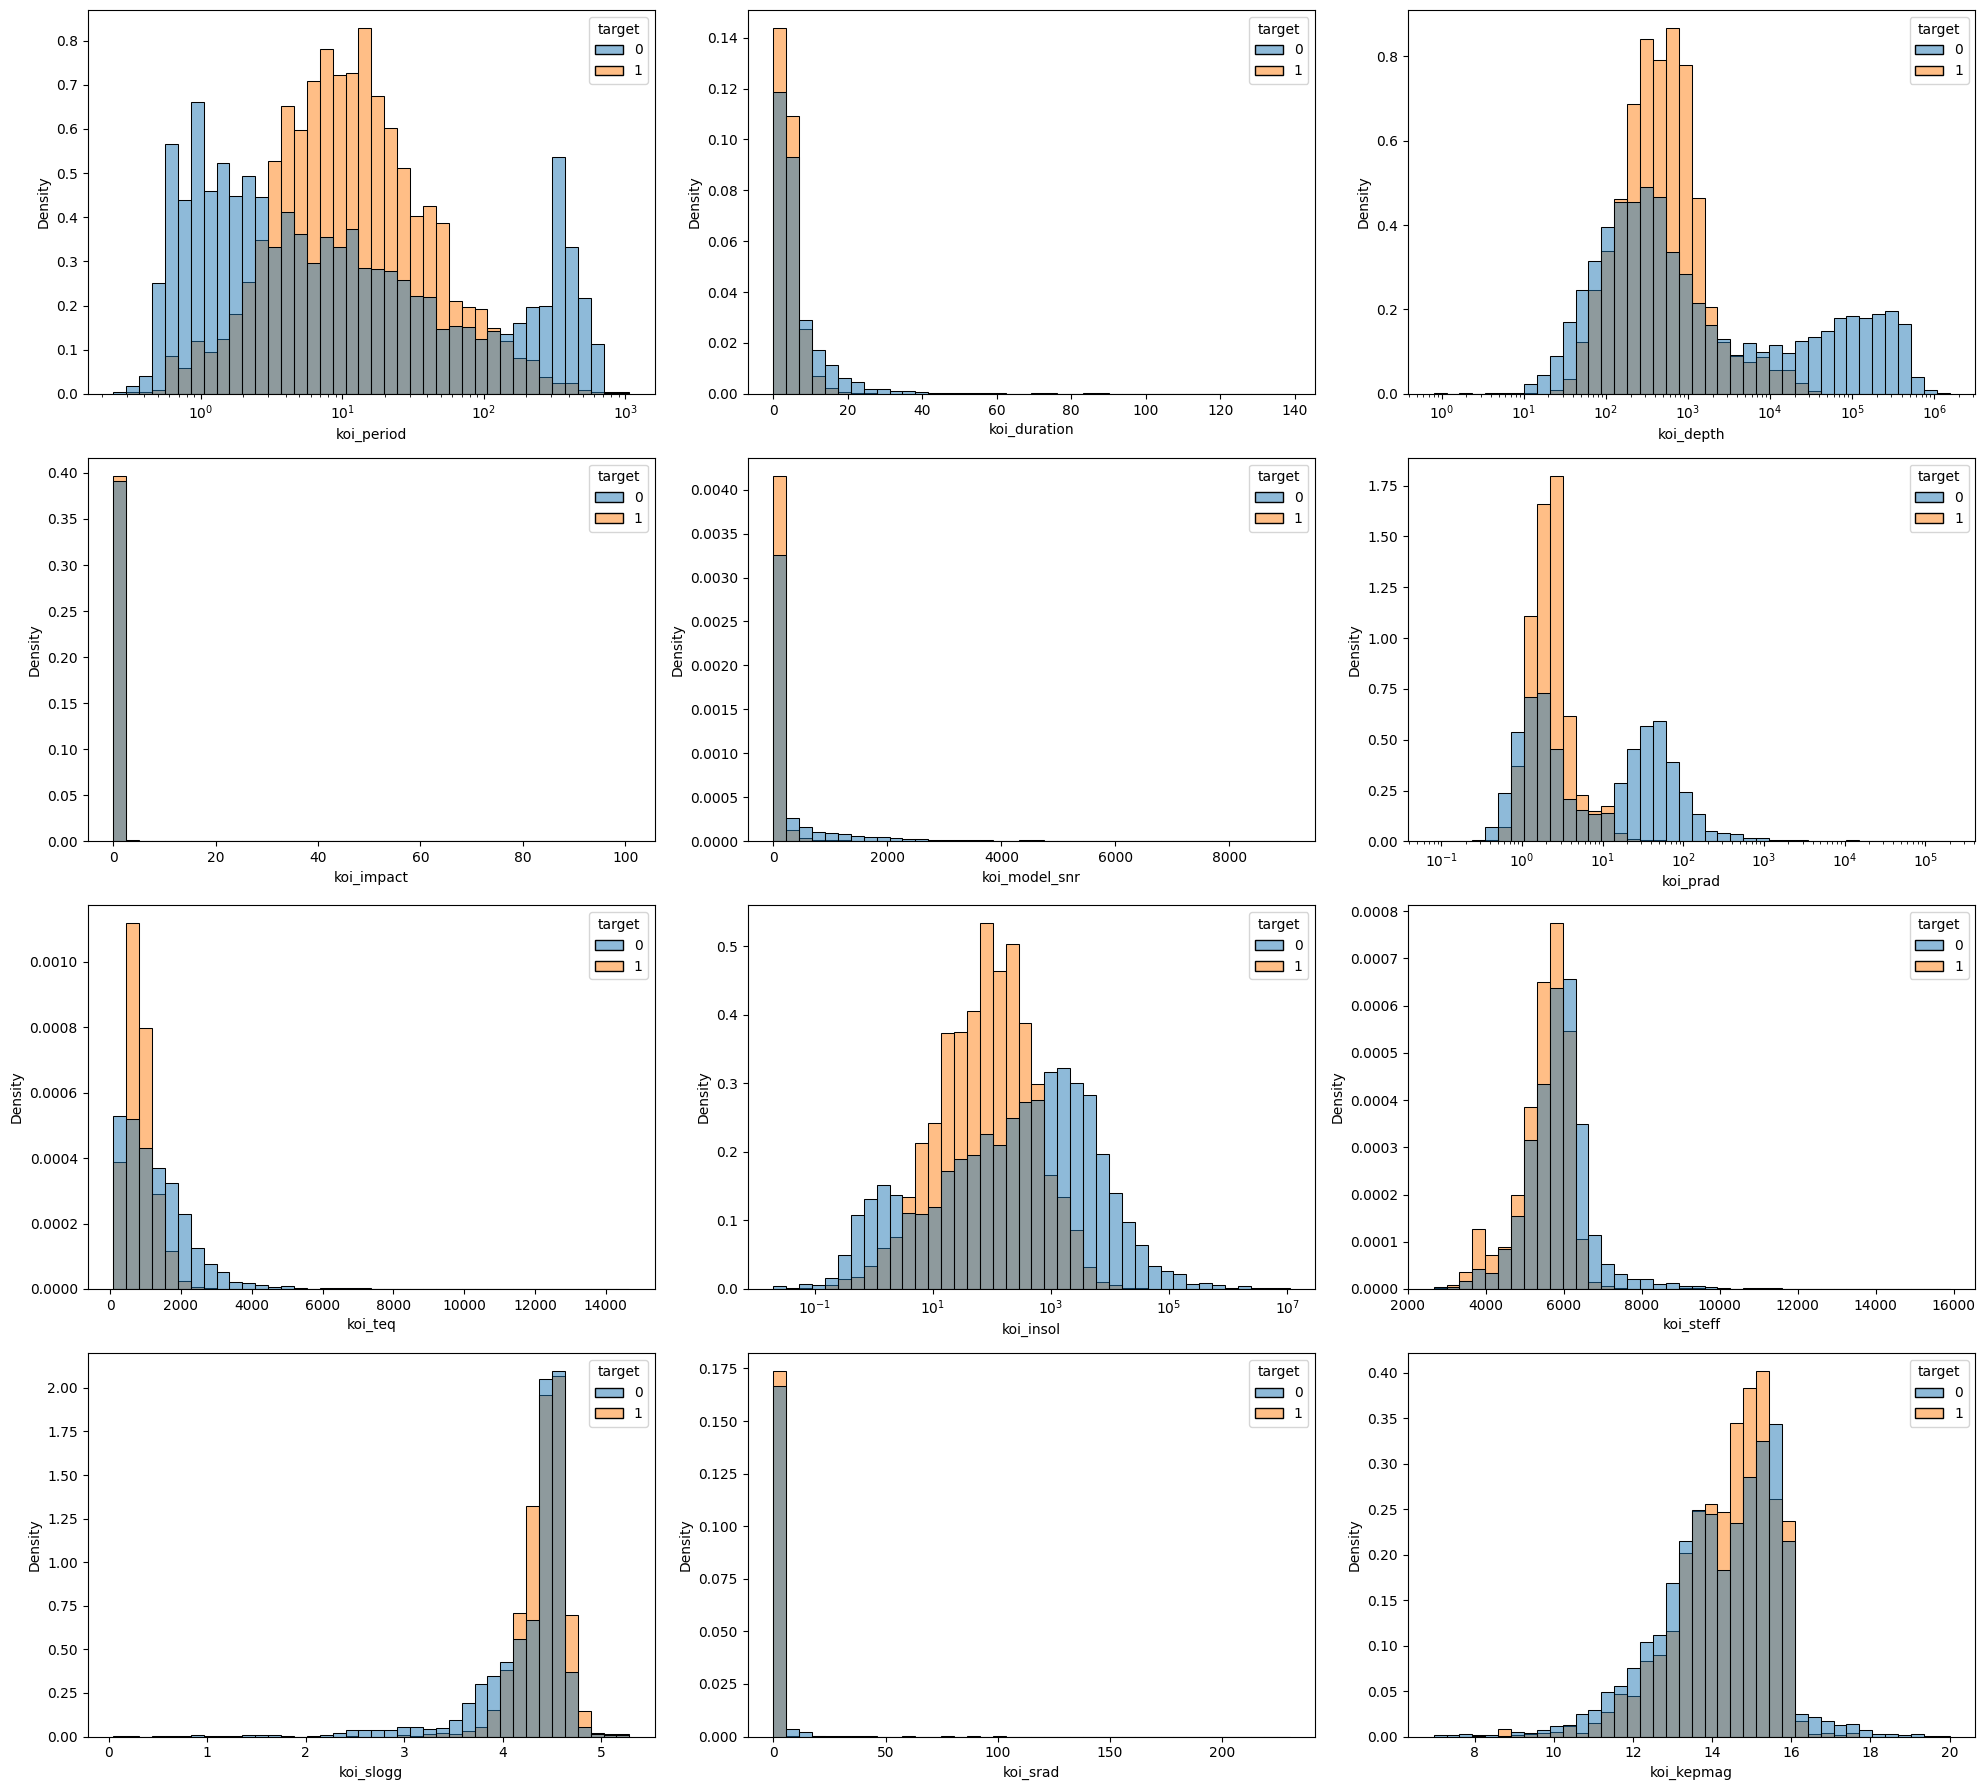

In [ ]:
# Distribución de cada variable según la clase (escala log en las muy sesgadas)
log_cols = ["koi_period", "koi_depth", "koi_prad", "koi_insol"]
fig, axes = plt.subplots(4, 3, figsize=(20, 18))
for ax, col in zip(axes.ravel(), features):
    sns.histplot(data=df_kepler_copy, x=col, hue="target", bins=40,
                 log_scale=col in log_cols, stat="density", common_norm=False, ax=ax)
plt.tight_layout()
plt.show()

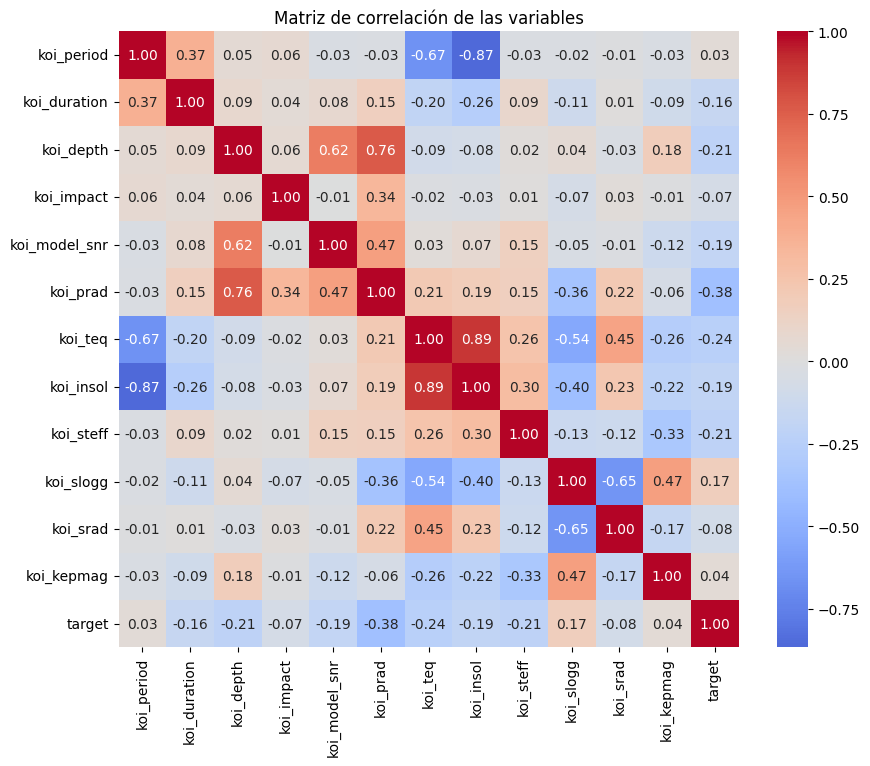

In [ ]:
df_log = df_kepler_copy.copy()
df_log[log_cols] = np.log1p(df_log[log_cols])

plt.figure(figsize=(10, 8))
sns.heatmap(df_log.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de correlación de las variables")
plt.show()

**Observaciones de la matriz de correlación** (variables sesgadas transformadas con `log1p`):

- La variable más relacionada con la variable objetivo es `koi_prad` (−0,38): los planetas confirmados tienden a ser más pequeños. Le siguen `koi_teq` (−0,24), `koi_depth` y `koi_steff` (−0,21). Ninguna variable por sí sola tiene una correlación alta con `target`, lo que anticipa un rendimiento limitado para un modelo lineal.
- Hay multicolinealidad física entre varias entradas: `koi_teq`–`koi_insol` (0,89), `koi_period`–`koi_insol` (−0,87), `koi_depth`–`koi_prad` (0,76) y `koi_slogg`–`koi_srad` (−0,65). Esto no impide predecir, pero hace que los pesos individuales del perceptrón sean menos interpretables.
- `koi_period` casi no se relaciona con el objetivo por sí sola (0,01), pero se mantiene porque está fuertemente asociada con otras variables y puede aportar en combinación.

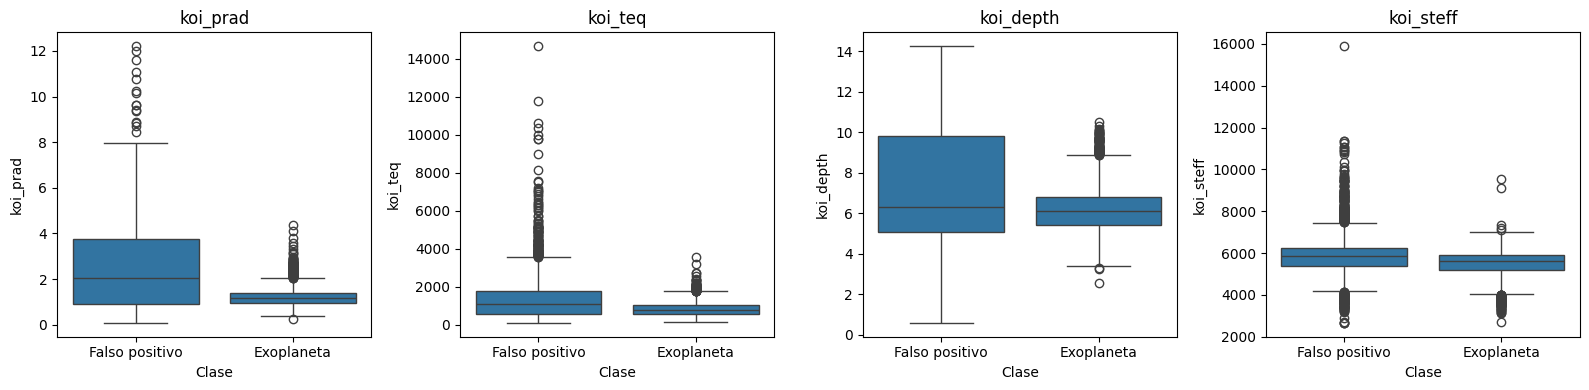

In [ ]:
cols_box = ["koi_prad", "koi_teq", "koi_depth", "koi_steff"]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, col in zip(axes, cols_box):
    sns.boxplot(x="target", y=col, data=df_log, ax=ax)
    ax.set_title(col)
    ax.set_xlabel("Clase")
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Falso positivo", "Exoplaneta"])

plt.tight_layout()
plt.show()

In [ ]:
# Verificacion valores menores a 1
print(df_kepler_copy[features].min())

koi_period          0.241843
koi_duration        0.104600
koi_depth           0.800000
koi_impact          0.000000
koi_model_snr       0.000000
koi_prad            0.080000
koi_teq            92.000000
koi_insol           0.020000
koi_steff        2661.000000
koi_slogg           0.047000
koi_srad            0.116000
koi_kepmag          6.966000
dtype: float64


In [ ]:
#Verificar asimetria
print(df_kepler_copy[features].skew().sort_values(ascending=False))

koi_insol        51.352513
koi_prad         45.668860
koi_impact       21.912499
koi_srad         20.298895
koi_duration      5.878854
koi_model_snr     4.644533
koi_depth         4.564145
koi_teq           3.192540
koi_period        2.848105
koi_steff         0.902442
koi_kepmag       -0.745892
koi_slogg        -3.399629
dtype: float64


In [ ]:
# División 80/20 estratificada (cada clase aporta el 20 % de sus filas al test)
rng = np.random.default_rng(42)
test_idx = []
for c in [0, 1]:
    idx = rng.permutation(y.index[y == c].to_numpy())
    test_idx.extend(idx[: int(0.2 * len(idx))])

X_test, y_test = X.loc[test_idx], y.loc[test_idx]
X_train, y_train = X.drop(index=test_idx), y.drop(index=test_idx)

print(f"Train: {X_train.shape}, % confirmados: {y_train.mean():.2%}")
print(f"Test:  {X_test.shape}, % confirmados: {y_test.mean():.2%}")

Train: (5613, 12), % confirmados: 32.67%
Test:  (1402, 12), % confirmados: 32.67%


In [ ]:
#Aplicar log1p
log_cols = ["koi_period", "koi_duration", "koi_depth", "koi_impact", "koi_model_snr",
            "koi_prad", "koi_teq", "koi_insol", "koi_srad"]

df_final = df_kepler_copy.copy()
df_final[log_cols] = np.log1p(df_final[log_cols])

In [ ]:
print(df_final[features].skew().sort_values(ascending=False))

koi_srad         4.065447
koi_impact       3.786388
koi_prad         1.231229
koi_model_snr    1.034491
koi_depth        0.963360
koi_duration     0.926068
koi_steff        0.902442
koi_period       0.721502
koi_insol        0.135548
koi_teq         -0.090489
koi_kepmag      -0.745892
koi_slogg       -3.399629
dtype: float64


In [76]:
# funciones del lab
def accuracy(y_true, y_pred):
    """Accuracy para clasificación."""
    return np.mean(y_true == y_pred)


def precision(y_true, y_pred):
    """Precisión: de los predichos positivos, cuántos lo son realmente."""
    TP = sum((y_true == 1) & (y_pred == 1))
    FP = sum((y_true == 0) & (y_pred == 1))
    if TP + FP == 0:
        return 0
    return TP / (TP + FP)

In [77]:
def recall(y_true, y_pred):
  """ De los positivos reales, cuántos lo predice el modelo """
  TP = sum((y_true == 1) & (y_pred == 1))
  FN = sum((y_true == 1) & (y_pred == 0))
  return TP / (TP + FN) if TP + FN > 0 else 0

def f1_score(y_true, y_pred):
  """ Media armónica de precisión y recall """
  p, r = precision(y_true, y_pred), recall(y_true, y_pred)
  return 2 * p * r / (p + r) if p + r > 0 else 0

## Referencias

<p style="padding-left: 2em; text-indent: -2em;">
Kaggle. (2017). <i>Kepler Exoplanet Search Results</i> cumulative.csv. NASA · Aleksey Bilogur. https://www.kaggle.com/datasets/nasa/kepler-exoplanet-search-results?resource=download
</p>

<p style="padding-left: 2em; text-indent: -2em;">
NASA Exoplanet Archive. (s. f.). <i>Kepler Objects of Interest (KOI) cumulative table</i> [Conjunto de datos]. NASA Exoplanet Science Institute, Caltech/IPAC. <a href="https://doi.org/10.26133/NEA4">https://doi.org/10.26133/NEA4</a>
</p>

<p style="padding-left: 2em; text-indent: -2em;">
NASA Exoplanet Archive. (2021, 11 de febrero). <i>Data columns in Kepler Objects of Interest table</i>. NASA Exoplanet Science Institute, Caltech/IPAC. Recuperado el 6 de octubre de 2026, de <a href="https://exoplanetarchive.ipac.caltech.edu/docs/API_kepcandidate_columns.html">https://exoplanetarchive.ipac.caltech.edu/docs/API_kepcandidate_columns.html</a>
</p>